**INTELIGÊNCIA ARTIFICIAL **

Prof. Marcones Cleber - pro21001731@cefsa.edu.br

## Métricas de Desempenho com Regressão Logistíca e k-NN

In [ ]:
# Importando as bibliotecas necessárias
# Metricas usadas para comparacoes

!pip install yellowbrick
from yellowbrick.classifier import ROCAUC
from sklearn.metrics import f1_score, ConfusionMatrixDisplay, RocCurveDisplay, confusion_matrix, classification_report, roc_auc_score, accuracy_score, precision_score, recall_score

# Importando o modelo que sera utilizado
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Carregamento de dados do OpenML
from sklearn.datasets import fetch_openml

# Plot dos gráficos
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import colors
import seaborn as sns

# Tratamento de dados
import pandas as pd
from collections import Counter



Métrica de Desempenho de Classificação

Vamos usar dados do https://www.openml.org/d/37

Fazendo a análise exploratória de Dados:

In [ ]:
# Vamos carregar dados publicos
diabetes = fetch_openml(data_id=37)

/usr/local/lib/python3.10/dist-packages/sklearn/datasets/_openml.py:1022: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


In [ ]:
# checando a dimensao dos dados recebidos
diabetes.data.shape

(768, 8)

In [ ]:
# nome das features disponiveis
diabetes.feature_names

['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']

In [ ]:
# Separando as colunas de features para analisar esses dados
dados = pd.DataFrame(data=diabetes.data, columns = diabetes.feature_names)

In [ ]:
dados.head()

,preg,plas,pres,skin,insu,mass,pedi,age
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0


In [ ]:
dados.describe()

,preg,plas,pres,skin,insu,mass,pedi,age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


array([[<Axes: title={'center': 'preg'}>,
        <Axes: title={'center': 'plas'}>,
        <Axes: title={'center': 'pres'}>],
       [<Axes: title={'center': 'skin'}>,
        <Axes: title={'center': 'insu'}>,
        <Axes: title={'center': 'mass'}>],
       [<Axes: title={'center': 'pedi'}>,
        <Axes: title={'center': 'age'}>, <Axes: >]], dtype=object)

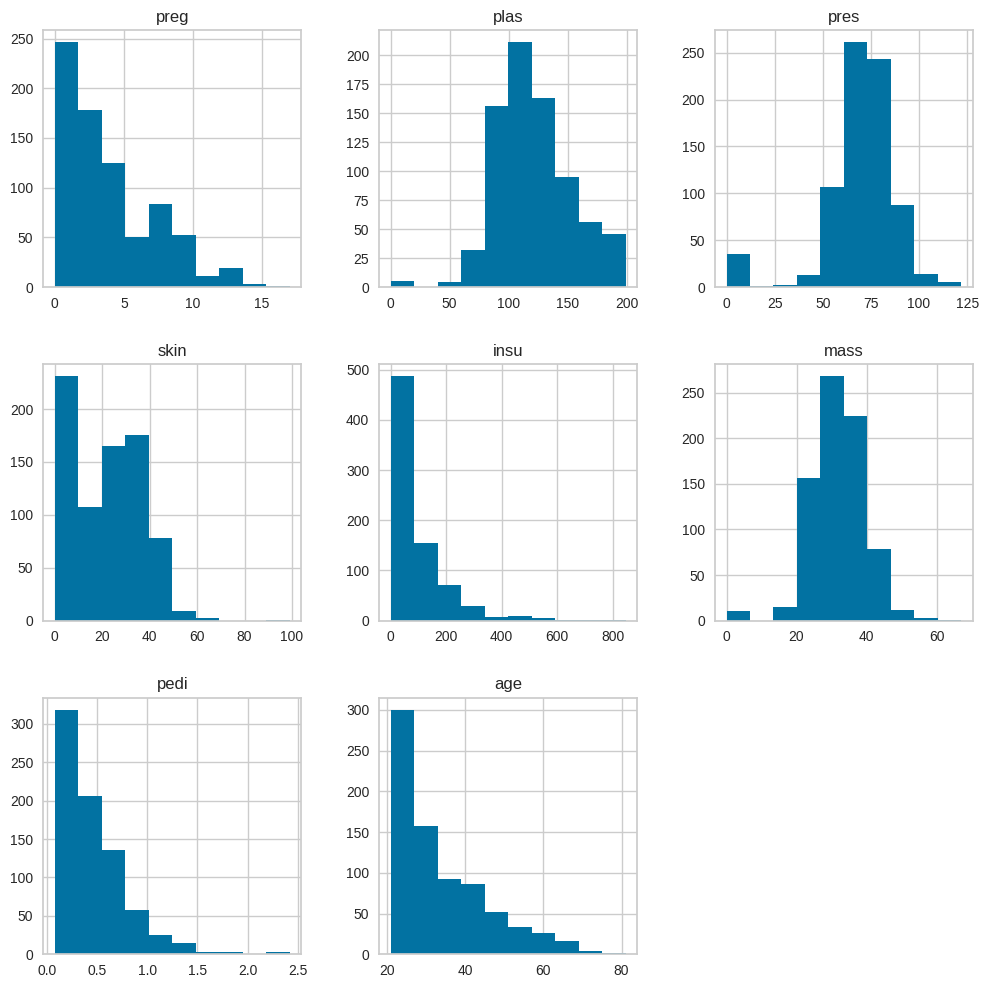

In [ ]:
dados.hist(figsize=(12,12))

Alguns dos nossos dados não estão seguindo uma distribuição gaussiana. Assim, vamos ter que normalizar os nossos dados

# Criando o Modelo de Regressão Logistica


In [ ]:
# Vendo a distribuição das classes
Counter(diabetes.target)

Counter({'tested_positive': 268, 'tested_negative': 500})

In [ ]:
# Dividindo os dados no conjunto de teste e treinamento
X_train, X_test, y_train, y_test = train_test_split(diabetes.data, diabetes.target, test_size=0.3, random_state=42)

# Aplicando a padronizacao
# levantando os minimos e maximos
scaler = MinMaxScaler().fit(X_train)
# Mudando a escala dos dados
x_train_scaled = scaler.transform(X_train)
x_test_scaled = scaler.transform(X_test)

# Fazendo a regressao logistica
log_reg = LogisticRegression()
log_reg.fit(x_train_scaled, y_train)

# Fazendo as predições
y_pred = log_reg.predict(x_test_scaled)

In [ ]:
# Checando 20 primeiras saidas das previsoes
y_pred[:20]

array(['tested_negative', 'tested_negative', 'tested_negative',
       'tested_negative', 'tested_negative', 'tested_negative',
       'tested_negative', 'tested_negative', 'tested_positive',
       'tested_positive', 'tested_negative', 'tested_positive',
       'tested_negative', 'tested_negative', 'tested_negative',
       'tested_negative', 'tested_negative', 'tested_negative',
       'tested_positive', 'tested_negative'], dtype=object)

In [ ]:
# Checando as 20 primeiras saidas dos labels
y_test[:20]

,class
668,tested_negative
324,tested_negative
624,tested_negative
690,tested_negative
473,tested_negative
204,tested_negative
97,tested_negative
336,tested_negative
568,tested_negative
148,tested_negative


In [ ]:
# Comparando usando o DataFrame
pd.DataFrame({'pred': y_pred, 'resp': y_test})

,pred,resp
668,tested_negative,tested_negative
324,tested_negative,tested_negative
624,tested_negative,tested_negative
690,tested_negative,tested_negative
473,tested_negative,tested_negative
...,...,...
619,tested_negative,tested_positive
198,tested_negative,tested_positive
538,tested_negative,tested_negative
329,tested_negative,tested_negative


A boa notícia é que não precisamos comparar cada um dos dados manualmente. O próprio sklearn possui as métricas que aprendemos anteriormente.

# Avaliando as métricas do nosso modelo

Primeiro vamos analisar pelas classes se há discrepância na classificação:

In [ ]:
# Vendo a distribuição das classes
Counter(y_test)

Counter({'tested_negative': 151, 'tested_positive': 80})

In [ ]:
# Vendo a distribuição das classes
Counter(y_pred)

Counter({'tested_negative': 162, 'tested_positive': 69})

Numa primeira análise, sem as métricas das aula, parece muito promissor o resultado obtido

Vamos checar a matriz de confusao:

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels = ['tested_positive','tested_negative'])
cm

array([[ 45,  35],
       [ 24, 127]])

Vamos visulizar a figura da matriz de confusão

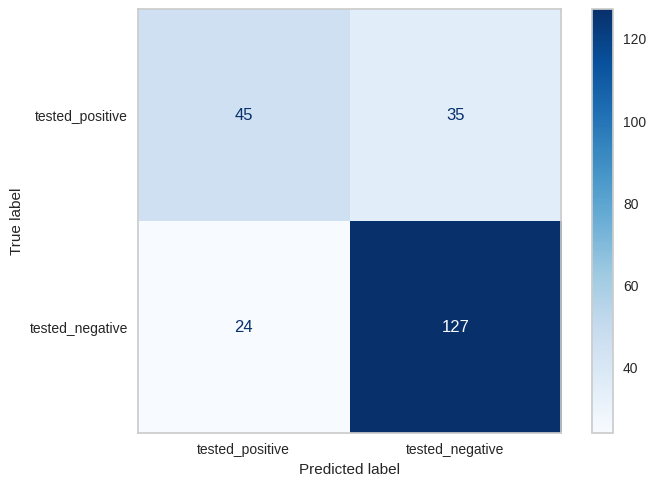

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['tested_positive','tested_negative'])
disp.plot(cmap='Blues')
plt.grid(False)
plt.show()
'''
 | TP | FN |
 | FP | TN |
 '''


Começando com a precisão:

$precisao = \frac{TP}{TP+FP}$

In [ ]:
# Calculando a precisão para o "tested negative"
precision_score(y_test, y_pred, pos_label='tested_positive')

0.6521739130434783

In [ ]:
# Precisao para o nosso modelo
precisao = 45/(45+24)
precisao

0.6521739130434783

Calculando a revocação:

$revocacao = \frac{TP}{TP+FN}$

In [ ]:
recall_score(y_test, y_pred, pos_label='tested_positive')

0.5625

In [ ]:
# revocacao para o nosso modelo
revocacao = 45/(45+35)
revocacao

0.5625

Calculando o f1 score:

$F_{1} = 2\times\frac{precisao \times revocacao}{precisao + revocacao}$

In [ ]:
f1_score(y_test, y_pred, pos_label='tested_positive')

0.6040268456375839

In [ ]:
# f1 score para o nosso modelo
f1 = 2*(precisao*revocacao)/(precisao+revocacao)
f1

0.6040268456375839

Calculando a acurácia:

$acuracia = \frac{TP+TN}{TP+TN+FP+FN}$

In [ ]:
# Acuracia para o nosso modelo
accuracy_score(y_test, y_pred)

0.7445887445887446

In [ ]:
# Comparando com o que vimos em aula
acuracia = (127+45)/(127+24+35+45)
acuracia

0.7445887445887446

**Exercício 1)** Recalcular as métricas de acurácia, revocação e f1 score do estudo acima considerando que a classe positiva dos nossos estudos é o 'tested_negative'

A partir dos resultados, o que podemos concluir dos resultados do nosso modelo?

Vamos agora checar a curva ROC do nosso modelo:

In [ ]:
y_score = log_reg.predict_proba(x_test_scaled)
y_score.shape

(231, 2)

In [ ]:
# Primeiro vamos levar o valor das probabilidades, isto é, os valores sem aplicarmos a classificacao.
y_score = log_reg.predict_proba(x_test_scaled)[:,1]
# Calculando o valor da AUC para o nosso modelo
roc_auc = roc_auc_score(y_test,y_score)
roc_auc

0.7964403973509934

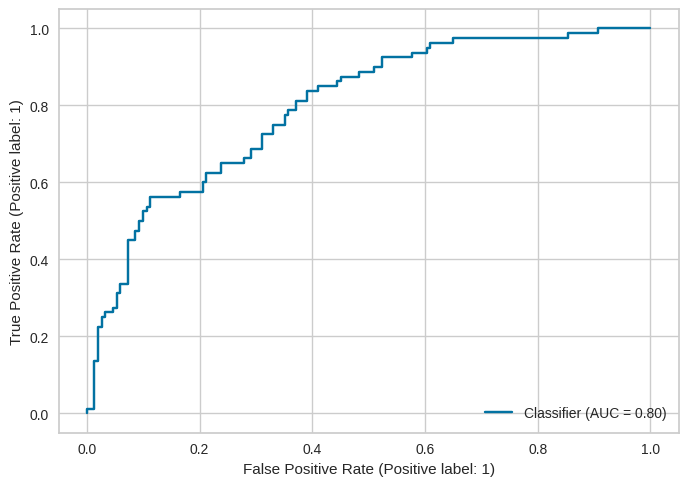

In [ ]:
# prompt: plote a curva ROC

# Convert string labels to numerical values
y_test_numeric = [1 if label == 'tested_positive' else 0 for label in y_test]

RocCurveDisplay.from_predictions(y_test_numeric, y_score)
plt.show()
